<a href="https://colab.research.google.com/github/chintu101/Cascading-Classifier-Anomaly-Detection/blob/main/minor_project_tier_2_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os

os.environ['KAGGLE_KEY'] = "42aedd1d581d01de29a196e1da7a4de1"

!kaggle datasets download -d amanalisiddiqui/fraud-detection-dataset
!unzip -o fraud-detection-dataset.zip

Dataset URL: https://www.kaggle.com/datasets/amanalisiddiqui/fraud-detection-dataset
License(s): MIT
100% 178M/178M [00:02<00:00, 64.0MB/s]

Archive:  fraud-detection-dataset.zip
  inflating: AIML Dataset.csv        


In [2]:
!pip install xgboost imbalanced-learn shap --quiet

In [3]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve,
    average_precision_score, precision_recall_curve,
    f1_score, precision_score, recall_score,
    accuracy_score, matthews_corrcoef, balanced_accuracy_score
)
from xgboost import XGBClassifier

RANDOM_STATE = 42

In [4]:
df = pd.read_csv('AIML Dataset.csv')
print(f'Dataset shape: {df.shape}')
print(df.head())

Dataset shape: (6362620, 11)
   step      type    amount     nameOrig  oldbalanceOrg  newbalanceOrig  \
0     1   PAYMENT   9839.64  C1231006815       170136.0       160296.36   
1     1   PAYMENT   1864.28  C1666544295        21249.0        19384.72   
2     1  TRANSFER    181.00  C1305486145          181.0            0.00   
3     1  CASH_OUT    181.00   C840083671          181.0            0.00   
4     1   PAYMENT  11668.14  C2048537720        41554.0        29885.86   

      nameDest  oldbalanceDest  newbalanceDest  isFraud  isFlaggedFraud  
0  M1979787155             0.0             0.0        0               0  
1  M2044282225             0.0             0.0        0               0  
2   C553264065             0.0             0.0        1               0  
3    C38997010         21182.0             0.0        1               0  
4  M1230701703             0.0             0.0        0               0  


# To Auto Detect Target Column

In [5]:
FRAUD_KEYWORDS = ['fraud', 'isfraud', 'is_fraud', 'label', 'class', 'target']
TARGET_COL = None
for col in df.columns:
    if col.lower() in FRAUD_KEYWORDS:
        TARGET_COL = col
        break
if TARGET_COL is None:
    binary_cols = [c for c in df.columns if df[c].nunique() == 2]
    TARGET_COL = binary_cols[0] if binary_cols else df.columns[-1]

print(f'\nTarget column: "{TARGET_COL}"')
print(df[TARGET_COL].value_counts())
print(f'Fraud rate: {df[TARGET_COL].mean() * 100:.4f}%')


Target column: "isFraud"
isFraud
0    6354407
1       8213
Name: count, dtype: int64
Fraud rate: 0.1291%


# Pre-Processing

In [6]:
df = df.copy()

for col in df.select_dtypes(include=['object', 'category']).columns:
    if col == TARGET_COL:
        continue
    df[col] = LabelEncoder().fit_transform(df[col].astype(str))

df.dropna(subset=[TARGET_COL], inplace=True)
num_cols = [c for c in df.select_dtypes(include=[np.number]).columns if c != TARGET_COL]
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

X = df.drop(columns=[TARGET_COL])
y = df[TARGET_COL].astype(int)
FEATURE_NAMES = list(X.columns)

# Train-Test Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)
print(f'\nTrain: {X_train.shape[0]:,} | Test: {X_test.shape[0]:,}')
print(f'Train fraud: {y_train.sum():,} | Test fraud: {y_test.sum():,}')


Train: 5,090,096 | Test: 1,272,524
Train fraud: 6,570 | Test fraud: 1,643


# Handling Class Imbalance

In [ ]:
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale_pw = neg / pos if pos > 0 else 1.0
print(f'\nscale_pos_weight = {scale_pw:.2f}  (neg/pos = {neg}/{pos})')


scale_pos_weight = 773.75  (neg/pos = 5083526/6570)


# Training XGBoost Model

In [ ]:
print('\nTraining XGBoost')

model = XGBClassifier(
    n_estimators     = 300,
    max_depth        = 6,
    learning_rate    = 0.05,
    subsample        = 0.8,
    colsample_bytree = 0.8,
    min_child_weight = 5,
    gamma            = 0.1,
    reg_alpha        = 0.1,
    reg_lambda       = 1.0,
    scale_pos_weight = scale_pw,
    eval_metric      = 'aucpr',
    tree_method      = 'hist',
    random_state     = RANDOM_STATE,
    verbosity        = 0
)

model.fit(
    X_train, y_train,
    eval_set = [(X_test, y_test)],
    verbose  = False
)
print('Training completed')


Training XGBoost
Training completed


# Prediction and Threshold Tuning

In [ ]:
proba = model.predict_proba(X_test)[:, 1]

thresholds     = np.arange(0.1, 0.9, 0.01)
f1_scores      = [f1_score(y_test, (proba >= t).astype(int), zero_division=0) for t in thresholds]
best_threshold = thresholds[np.argmax(f1_scores)]
print(f'Best threshold (max F1): {best_threshold:.2f}')

pred = (proba >= best_threshold).astype(int)

Best threshold (max F1): 0.89


# Evaluation

In [ ]:
print('\n' + '='*50)
print('XGBoost — EVALUATION RESULTS')
print('='*50)
print(classification_report(y_test, pred, target_names=['Legitimate', 'Fraudulent']))

metrics = {
    'Accuracy':          accuracy_score(y_test, pred),
    'Balanced Accuracy': balanced_accuracy_score(y_test, pred),
    'Precision (Fraud)': precision_score(y_test, pred, zero_division=0),
    'Recall (Fraud)':    recall_score(y_test, pred, zero_division=0),
    'F1-Score (Fraud)':  f1_score(y_test, pred, zero_division=0),
    'ROC-AUC':           roc_auc_score(y_test, proba),
    'Avg Precision':     average_precision_score(y_test, proba),
    'MCC':               matthews_corrcoef(y_test, pred)
}
print('Metrics Summary:')
for k, v in metrics.items():
    print(f'  {k:<25}: {v:.4f}')

#pd.DataFrame([metrics]).to_csv('xgboost_results.csv', index=False)
#print('\nResults saved to xgboost_results.csv')


XGBoost — EVALUATION RESULTS
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00   1270881
  Fraudulent       0.56      0.97      0.71      1643

    accuracy                           1.00   1272524
   macro avg       0.78      0.99      0.86   1272524
weighted avg       1.00      1.00      1.00   1272524

Metrics Summary:
  Accuracy                 : 0.9990
  Balanced Accuracy        : 0.9867
  Precision (Fraud)        : 0.5623
  Recall (Fraud)           : 0.9744
  F1-Score (Fraud)         : 0.7131
  ROC-AUC                  : 0.9998
  Avg Precision            : 0.9606
  MCC                      : 0.7399

Results saved to xgboost_results.csv


# Figures

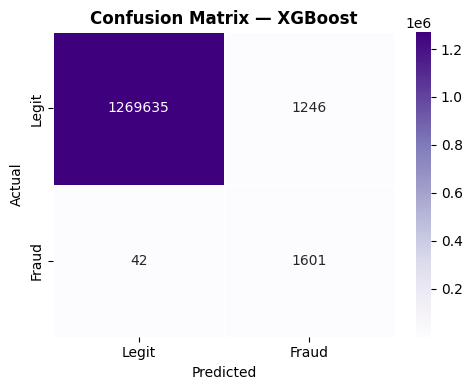

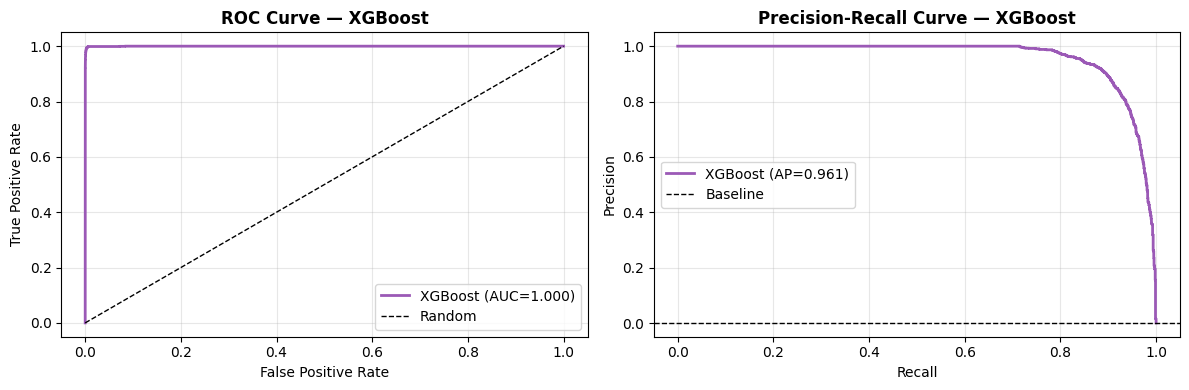

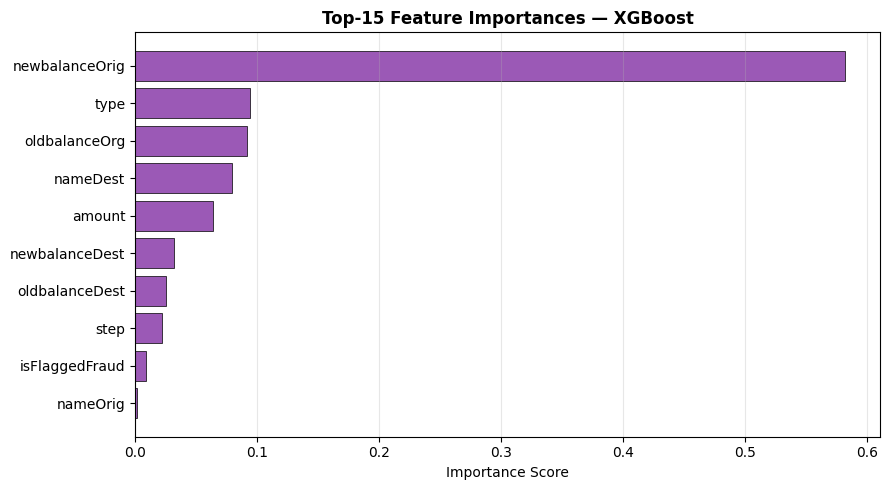

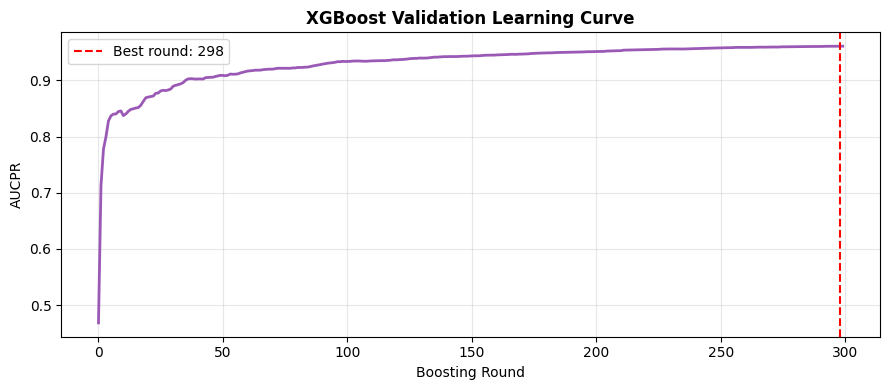


Computing SHAP values...


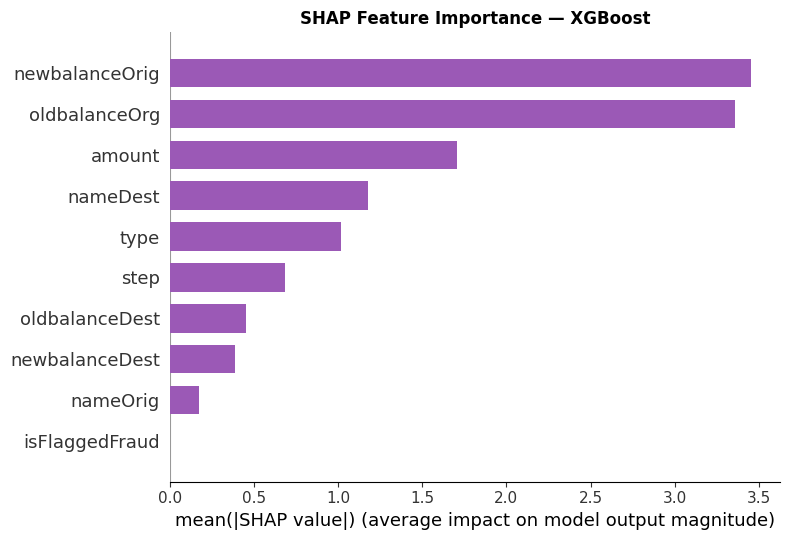


Saved files:
  AIML Dataset.csv
  xgboost_confusion_matrix.png
  xgboost_feature_importance.png
  xgboost_learning_curve.png
  xgboost_results.csv
  xgboost_roc_pr.png
  xgboost_shap.png

XGBoost complete!


In [ ]:
# Confusion Matrix
fig, ax = plt.subplots(figsize=(5, 4))
cm = confusion_matrix(y_test, pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', ax=ax,
            xticklabels=['Legit', 'Fraud'],
            yticklabels=['Legit', 'Fraud'],
            linewidths=0.5)
ax.set_title('Confusion Matrix — XGBoost', fontweight='bold')
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
plt.tight_layout()
plt.savefig('xgboost_confusion_matrix.png', dpi=200, bbox_inches='tight')
plt.show()

# ROC + PR Curves
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

fpr, tpr, _ = roc_curve(y_test, proba)
axes[0].plot(fpr, tpr, color='#9B59B6', lw=2, label=f'XGBoost (AUC={roc_auc_score(y_test, proba):.3f})')
axes[0].plot([0,1],[0,1], 'k--', lw=1, label='Random')
axes[0].set_xlabel('False Positive Rate'); axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve — XGBoost', fontweight='bold')
axes[0].legend(); axes[0].grid(alpha=0.3)

prec, rec, _ = precision_recall_curve(y_test, proba)
axes[1].plot(rec, prec, color='#9B59B6', lw=2, label=f'XGBoost (AP={average_precision_score(y_test, proba):.3f})')
axes[1].axhline(y_test.mean(), color='k', lw=1, linestyle='--', label='Baseline')
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve — XGBoost', fontweight='bold')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('xgboost_roc_pr.png', dpi=200, bbox_inches='tight')
plt.show()

# Feature Importance
feat_imp = pd.Series(model.feature_importances_, index=FEATURE_NAMES).sort_values(ascending=False).head(15)
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(feat_imp.index[::-1], feat_imp.values[::-1], color='#9B59B6', edgecolor='black', lw=0.5)
ax.set_xlabel('Importance Score'); ax.grid(axis='x', alpha=0.3)
ax.set_title('Top-15 Feature Importances — XGBoost', fontweight='bold')
plt.tight_layout()
plt.savefig('xgboost_feature_importance.png', dpi=200, bbox_inches='tight')
plt.show()

# Learning Curve
results_log = model.evals_result()
if results_log:
    metric_key = list(results_log['validation_0'].keys())[0]
    val_scores  = results_log['validation_0'][metric_key]
    fig, ax = plt.subplots(figsize=(9, 4))
    ax.plot(val_scores, color='#9B59B6', lw=2)
    best_i = np.argmax(val_scores)
    ax.axvline(best_i, color='red', linestyle='--', lw=1.5, label=f'Best round: {best_i}')
    ax.set_xlabel('Boosting Round'); ax.set_ylabel(metric_key.upper())
    ax.set_title('XGBoost Validation Learning Curve', fontweight='bold')
    ax.legend(); ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig('xgboost_learning_curve.png', dpi=200, bbox_inches='tight')
    plt.show()

# Fig 5: SHAP Summary
print('\nComputing SHAP values...')
explainer   = shap.TreeExplainer(model)
sample_size = min(500, len(X_test))
X_shap      = X_test.sample(n=sample_size, random_state=RANDOM_STATE)
shap_values = explainer.shap_values(X_shap)

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_shap, plot_type='bar', show=False, color='#9B59B6')
plt.title('SHAP Feature Importance — XGBoost', fontweight='bold')
plt.tight_layout()
plt.savefig('xgboost_shap.png', dpi=200, bbox_inches='tight')
plt.show()

print('\nSaved files:')
for f in sorted(os.listdir('.')):
    if f.startswith('xgboost') or f.endswith('.csv'):
        print(f'  {f}')
print('\nXGBoost complete!')

Saving the model

